**TASK 2:MOVIE RATING PREDICTION WITH PYTHON**

**Build a model that predicts the rating of a movie based on
features like genre, director, and actors. You can use regression
techniques to tackle this problem.
The goal is to analyze historical movie data and develop a model
that accurately estimates the rating given to a movie by users or
critics.
Movie Rating Prediction project enables you to explore data
analysis, preprocessing, feature engineering, and machine
learning modeling techniques. It provides insights into the factors
that influence movie ratings and allows you to build a model that
can estimate the ratings of movies accurately.**

**Import Libraries**

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from xgboost import XGBRegressor


**Loading the Dataset**

In [37]:
df = pd.read_csv("IMDb_Movies_India.csv",encoding='latin-1')
print(df.head())
print(df.info())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

**Data Preprocessing**

In [38]:
df = df.dropna(subset=['Rating'])
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')[0]
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Duration'] = df['Duration'].astype(str).str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
X = df[['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']
print(X.dtypes)
print(X.head())
print(y.head())

Year          int64
Duration    float64
Genre         int64
Votes         int64
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
dtype: object
   Year  Duration  Genre  Votes  Director  Actor 1  Actor 2  Actor 3
1  2019     109.0    268      8       811     1782     2815      377
3  2019     110.0    207     35      1749     1589      890     2572
5  1997     147.0    177    827      2005      508       85     2449
6  2005     142.0    331   1086      2643      931     1388     3030
8  2012      82.0    367    326       174     2521     1461     1205
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


**Model Training**

In [40]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Model Evaluation**

In [42]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.8078652633259995


**Visualization**

**i) HistPlot-Rating Distribution**

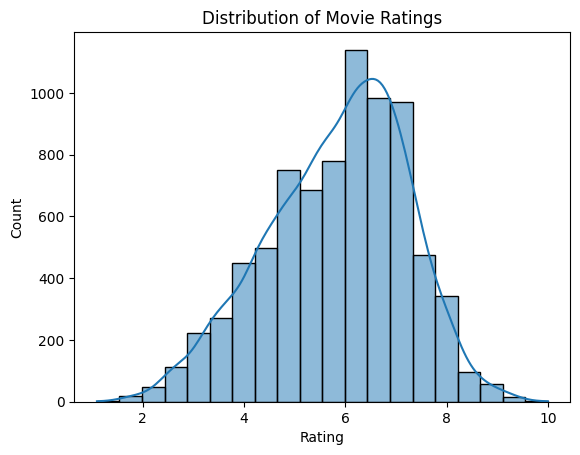

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Rating'],
             bins=20,
             kde=True)

plt.title("Distribution of Movie Ratings")
plt.show()

**ii) Correlation Heatmap**

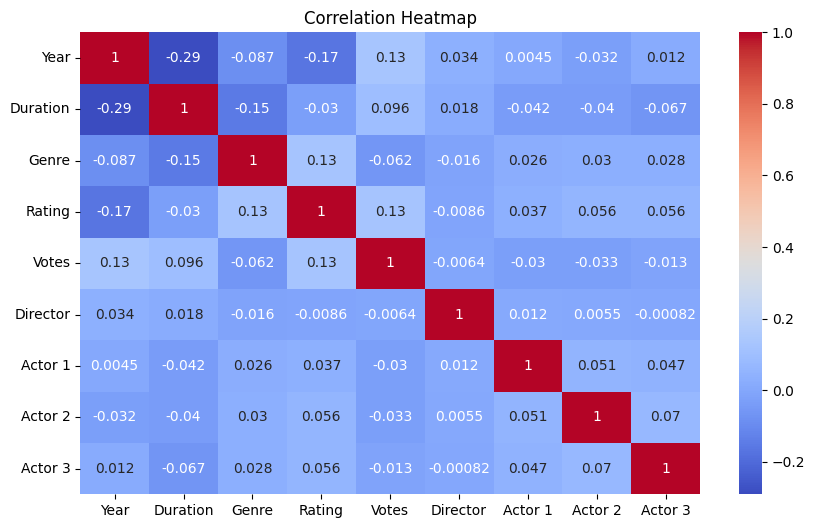

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()